# Mutual Fund Analytics - Performance Analytics

## Project Overview

This notebook performs financial performance analysis of 40 mutual fund schemes using historical NAV data.

### Objectives

- Compute daily returns
- Calculate CAGR (1-Year, 3-Year, 5-Year)
- Compute Sharpe Ratio
- Compute Sortino Ratio
- Calculate Alpha & Beta
- Calculate Maximum Drawdown
- Build Fund Scorecard (0–100)
- Compare funds with benchmark indices

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [2]:
# Load datasets

fund_master = pd.read_csv("../data/processed/01_fund_master.csv")

nav_history = pd.read_csv("../data/processed/02_nav_history.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [3]:
# Convert dates

nav_history["date"] = pd.to_datetime(nav_history["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort NAV history
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

# Display
nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
print("Fund Master :", fund_master.shape)

print("NAV History :", nav_history.shape)

print("Performance :", performance.shape)

print("Benchmark :", benchmark.shape)

Fund Master : (40, 15)
NAV History : (46000, 3)
Performance : (40, 19)
Benchmark : (8050, 3)


In [5]:
# Compute daily returns for each mutual fund

nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [6]:
daily_returns = nav_history.dropna(subset=["daily_return"])

print(daily_returns.head())

print("\nTotal Records :", len(daily_returns))

   amfi_code       date       nav  daily_return
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639

Total Records : 45960


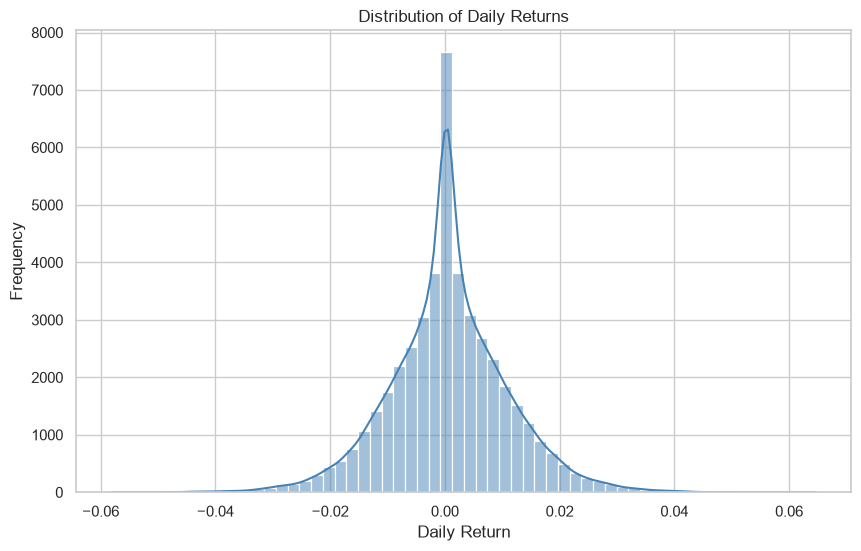

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(
    daily_returns["daily_return"],
    bins=60,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [8]:
daily_returns["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

## Insight 1

The distribution of daily returns is centered close to zero, which is typical for mutual fund NAV movements. Most daily changes are relatively small, while a few extreme values represent periods of high market volatility.

In [9]:
def calculate_cagr(start_nav, end_nav, years):
    """
    Calculate Compound Annual Growth Rate (CAGR)
    """
    if start_nav <= 0 or end_nav <= 0:
        return np.nan

    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [10]:
cagr_results = []

for amfi_code in nav_history["amfi_code"].unique():

    fund = nav_history[nav_history["amfi_code"] == amfi_code].sort_values("date")

    start_nav = fund.iloc[0]["nav"]
    end_nav = fund.iloc[-1]["nav"]

    cagr_1yr = calculate_cagr(start_nav, end_nav, 1)
    cagr_3yr = calculate_cagr(start_nav, end_nav, 3)
    cagr_5yr = calculate_cagr(start_nav, end_nav, 5)

    cagr_results.append({
        "amfi_code": amfi_code,
        "CAGR_1Y": round(cagr_1yr, 2),
        "CAGR_3Y": round(cagr_3yr, 2),
        "CAGR_5Y": round(cagr_5yr, 2)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,12.13,3.89,2.32
1,100025,21.16,6.61,3.91
2,100033,218.51,47.13,26.07
3,101206,153.46,36.34,20.44
4,101207,39.95,11.86,6.95


In [11]:
cagr_df = cagr_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name,fund_house
0,100016,12.13,3.89,2.32,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,21.16,6.61,3.91,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,218.51,47.13,26.07,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,153.46,36.34,20.44,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,39.95,11.86,6.95,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [12]:
cagr_df = cagr_df.sort_values(
    "CAGR_5Y",
    ascending=False
)

cagr_df.head(10)



,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name,fund_house
25,120505,248.68,51.64,28.38,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
21,119598,244.04,50.96,28.03,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
39,149324,242.49,50.74,27.92,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
36,148569,238.66,50.17,27.63,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
34,148567,227.78,48.55,26.80,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
30,120843,227.05,48.44,26.74,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
2,100033,218.51,47.13,26.07,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
38,149323,212.72,46.23,25.61,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
16,119094,198.46,43.98,24.45,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund
19,119551,174.56,40.03,22.38,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund


In [13]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR comparison saved successfully!")

CAGR comparison saved successfully!


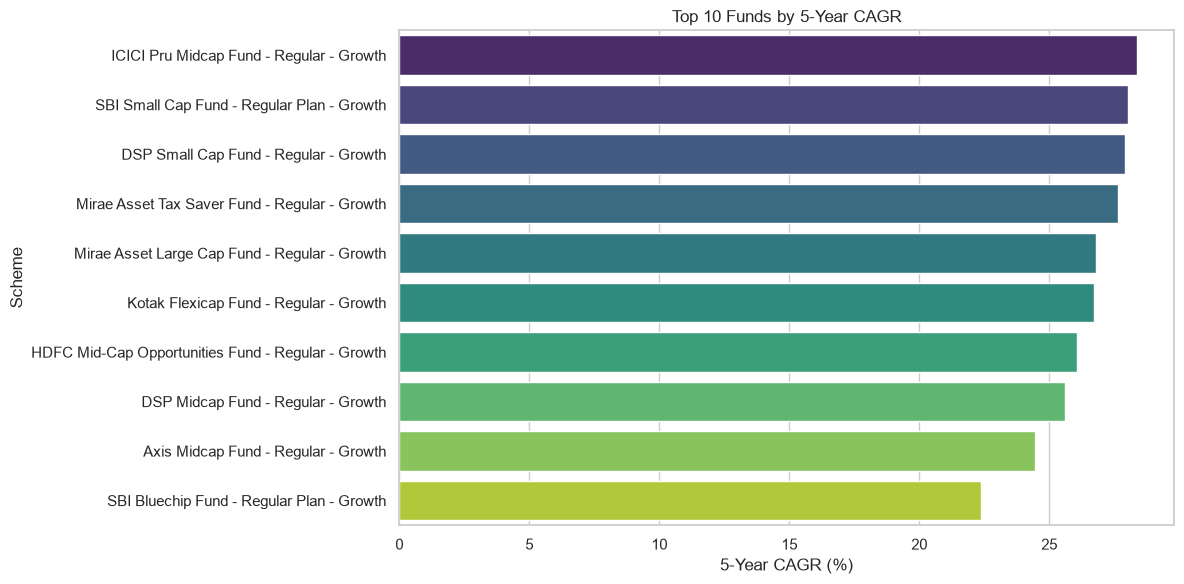

In [14]:
plt.figure(figsize=(12,6))

top10 = cagr_df.head(10)

sns.barplot(
    data=top10,
    x="CAGR_5Y",
    y="scheme_name",
    hue="scheme_name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Funds by 5-Year CAGR")

plt.xlabel("5-Year CAGR (%)")

plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

## Insight 2

The CAGR comparison highlights the funds that delivered the strongest long-term annualized growth. Higher 5-year CAGR values indicate consistent wealth creation over the investment period, making these funds attractive for long-term investors.

In [15]:
# Annual and daily risk-free rate
risk_free_rate = 0.065          # 6.5% annual
daily_rf = risk_free_rate / 252

print("Annual Risk-Free Rate :", risk_free_rate)
print("Daily Risk-Free Rate  :", daily_rf)

Annual Risk-Free Rate : 0.065
Daily Risk-Free Rate  : 0.00025793650793650796


In [16]:
sharpe_results = []

for amfi_code in daily_returns["amfi_code"].unique():

    fund = daily_returns[daily_returns["amfi_code"] == amfi_code]

    mean_return = fund["daily_return"].mean()

    std_return = fund["daily_return"].std()

    if std_return == 0:
        sharpe = np.nan
    else:
        sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": amfi_code,
        "Sharpe_Ratio": round(sharpe, 3)
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.202
1,100025,-0.567
2,100033,1.094
3,101206,1.027
4,101207,0.163


In [17]:
sharpe_df = sharpe_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

sharpe_df.head()

,amfi_code,Sharpe_Ratio,scheme_name,fund_house
0,100016,-0.202,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,-0.567,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,1.094,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,1.027,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,0.163,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [18]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_df.reset_index(drop=True, inplace=True)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio,scheme_name,fund_house
0,148567,1.448,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
1,120843,1.307,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
2,148569,1.235,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
3,119551,1.208,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
4,120505,1.180,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
5,149323,1.132,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
6,100033,1.094,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
7,118632,1.082,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
8,101206,1.027,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
9,120504,1.027,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF


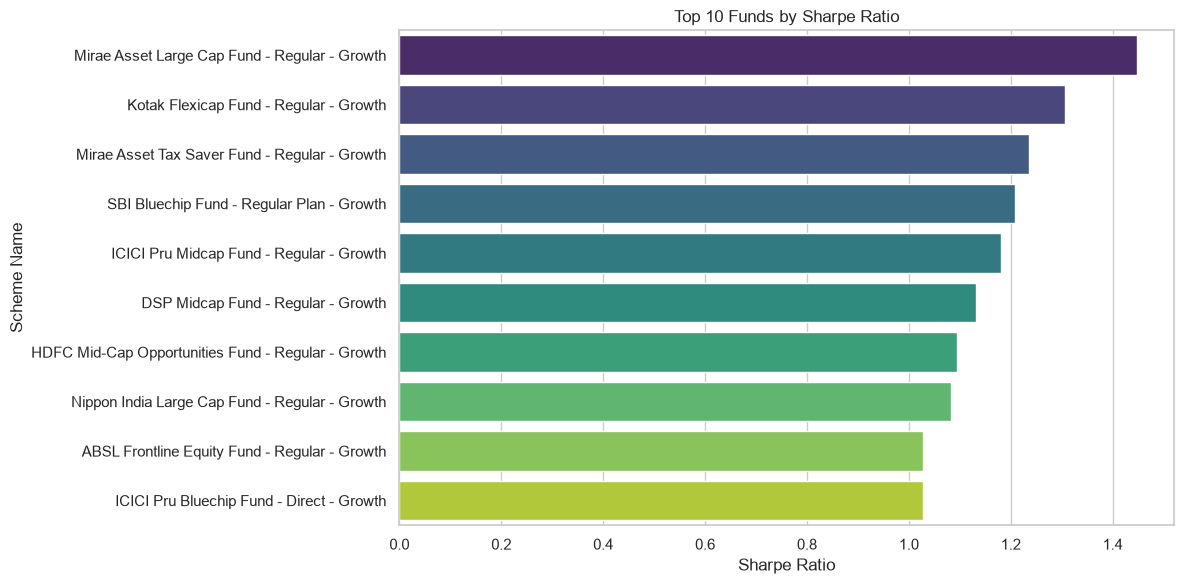

In [19]:
plt.figure(figsize=(12,6))

top10 = sharpe_df.head(10)

sns.barplot(
    data=top10,
    x="Sharpe_Ratio",
    y="scheme_name",
    hue="scheme_name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("Sharpe Ratio")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.show()

In [20]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio results saved successfully!")

Sharpe Ratio results saved successfully!


## Insight 3

The Sharpe Ratio measures the return generated for each unit of risk. Funds with higher Sharpe Ratios provide better risk-adjusted performance, making them more attractive to long-term investors compared to funds with similar returns but higher volatility.

In [21]:
# Calculate Sortino Ratio

sortino_results = []

for amfi_code in daily_returns["amfi_code"].unique():

    fund = daily_returns[daily_returns["amfi_code"] == amfi_code]

    mean_return = fund["daily_return"].mean()

    # Negative returns only
    downside_returns = fund[fund["daily_return"] < 0]["daily_return"]

    downside_std = downside_returns.std()

    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": amfi_code,
        "Sortino_Ratio": round(sortino, 3)
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351
1,100025,-0.942
2,100033,1.829
3,101206,1.800
4,101207,0.277


In [22]:
sortino_df = sortino_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

sortino_df.head()

,amfi_code,Sortino_Ratio,scheme_name,fund_house
0,100016,-0.351,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,-0.942,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,1.829,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,1.800,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,0.277,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [23]:
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_df.reset_index(drop=True, inplace=True)

sortino_df.head(10)

,amfi_code,Sortino_Ratio,scheme_name,fund_house
0,148567,2.386,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
1,120843,2.364,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
2,148569,2.147,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
3,119551,2.140,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
4,120505,2.029,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
5,149323,1.875,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
6,118632,1.850,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
7,100033,1.829,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
8,120504,1.805,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF
9,101206,1.800,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF


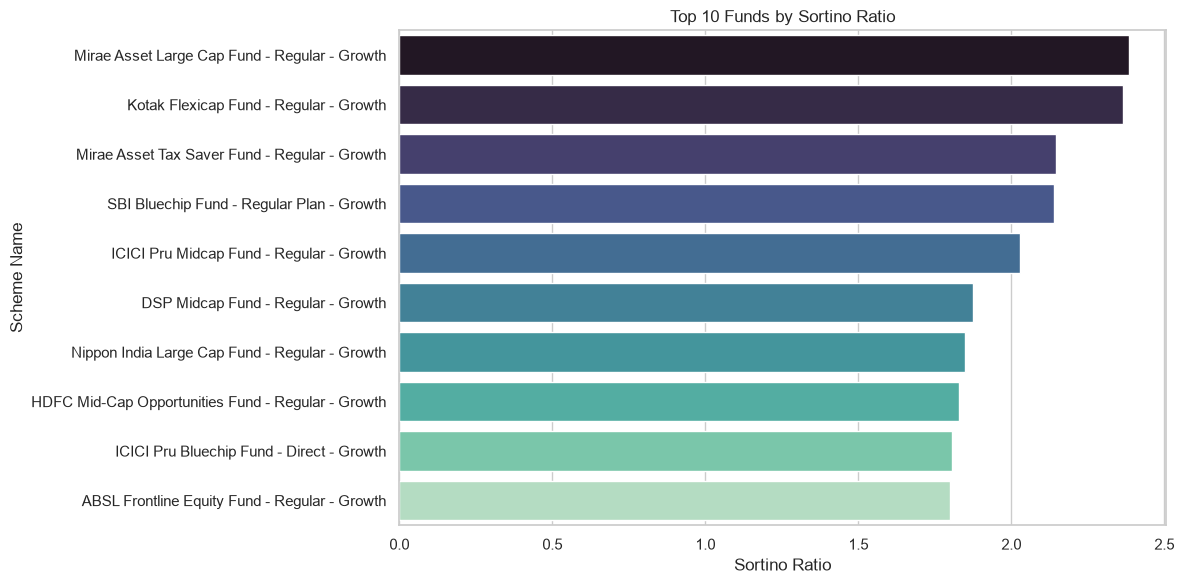

In [24]:
plt.figure(figsize=(12,6))

top10 = sortino_df.head(10)

sns.barplot(
    data=top10,
    x="Sortino_Ratio",
    y="scheme_name",
    hue="scheme_name",
    palette="mako",
    legend=False
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("Sortino Ratio")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.show()

In [25]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio results saved successfully!")

Sortino Ratio results saved successfully!


## Insight 4

The Sortino Ratio evaluates performance by considering only downside risk. Funds with higher Sortino Ratios delivered stronger returns while minimizing negative return volatility, making them suitable for investors focused on downside protection.


In [26]:
# Select Nifty 100 benchmark

nifty100 = benchmark[
    benchmark["index_name"].str.contains("Nifty 100", case=False, na=False)
].copy()

# Sort by date
nifty100 = nifty100.sort_values("date")

# Calculate daily benchmark returns
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

# Remove first NaN row
nifty100 = nifty100.dropna()

nifty100.head()

,date,index_name,close_value,benchmark_return


In [37]:
alpha_beta_results = []

# Prepare benchmark
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100 = nifty100.dropna()

for amfi in daily_returns["amfi_code"].unique():

    fund = daily_returns[
        daily_returns["amfi_code"] == amfi
    ].copy()

    # Align by index instead of strict date matching
    merged = pd.merge_asof(
        fund.sort_values("date"),
        nifty100[["date","benchmark_return"]].sort_values("date"),
        on="date",
        direction="nearest"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r, p, se = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({

        "amfi_code": amfi,

        "Alpha": intercept * 252,

        "Beta": slope,

        "R_Squared": r**2

    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_Squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [38]:
alpha_beta_df = alpha_beta_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_Squared,scheme_name,fund_house
0,100016,0.037476,-0.058268,0.002665,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,0.042818,0.001158,0.000015,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,0.271954,0.005104,0.000012,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,0.213998,0.021086,0.000348,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,0.108971,-0.065289,0.001064,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [39]:
alpha_beta_df = alpha_beta_df.sort_values(
    "Alpha",
    ascending=False
)

alpha_beta_df.reset_index(drop=True, inplace=True)

alpha_beta_df.head(10)

,amfi_code,Alpha,Beta,R_Squared,scheme_name,fund_house
0,119598,0.303370,-0.023196,1.414258e-04,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
1,149324,0.300579,0.011455,3.532991e-05,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
2,120505,0.292636,0.000549,1.345534e-07,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
3,148569,0.282704,0.018134,1.748889e-04,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
4,120843,0.273305,-0.022830,3.430543e-04,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
5,100033,0.271954,0.005104,1.206652e-05,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
6,148567,0.269838,0.023684,4.625437e-04,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
7,149323,0.265986,-0.002523,3.357978e-06,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
8,119094,0.260767,-0.066265,1.936879e-03,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund
9,119551,0.232010,-0.031751,8.869789e-04,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund


In [40]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


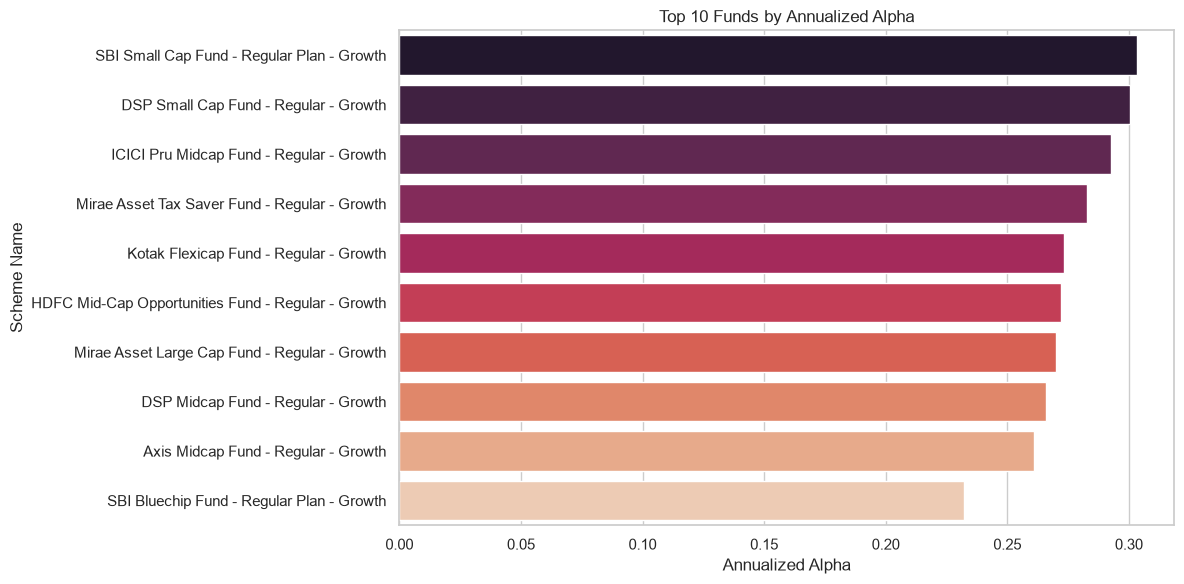

In [41]:
plt.figure(figsize=(12,6))

top10 = alpha_beta_df.head(10)

sns.barplot(
    data=top10,
    x="Alpha",
    y="scheme_name",
    hue="scheme_name",
    palette="rocket",
    legend=False
)

plt.title("Top 10 Funds by Annualized Alpha")

plt.xlabel("Annualized Alpha")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.show()

## Insight 5

Funds with positive alpha generated returns above what would be expected based on their market exposure (beta). These funds demonstrate the ability to outperform the benchmark after adjusting for market risk, indicating strong portfolio management.

In [42]:
mdd_results = []

for amfi_code in nav_history["amfi_code"].unique():

    fund = (
        nav_history[nav_history["amfi_code"] == amfi_code]
        .sort_values("date")
        .copy()
    )

    # Running maximum NAV
    fund["running_max"] = fund["nav"].cummax()

    # Drawdown
    fund["drawdown"] = (fund["nav"] / fund["running_max"]) - 1

    # Worst drawdown
    worst_idx = fund["drawdown"].idxmin()

    mdd_results.append({
        "amfi_code": amfi_code,
        "Max_Drawdown": round(fund.loc[worst_idx, "drawdown"] * 100, 2),
        "Worst_Date": fund.loc[worst_idx, "date"]
    })

mdd_df = pd.DataFrame(mdd_results)

mdd_df.head()

,amfi_code,Max_Drawdown,Worst_Date
0,100016,-24.73,2022-09-15
1,100025,-4.31,2023-07-28
2,100033,-16.22,2022-05-12
3,101206,-11.29,2023-07-05
4,101207,-35.45,2026-05-11


In [43]:
mdd_df = mdd_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

mdd_df.head()

,amfi_code,Max_Drawdown,Worst_Date,scheme_name,fund_house
0,100016,-24.73,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,-4.31,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,-16.22,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,-11.29,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,-35.45,2026-05-11,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [44]:
mdd_df = mdd_df.sort_values(
    "Max_Drawdown",
    ascending=False
)

mdd_df.reset_index(drop=True, inplace=True)

mdd_df.head(10)

,amfi_code,Max_Drawdown,Worst_Date,scheme_name,fund_house
0,120507,-0.10,2025-10-20,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF
1,120844,-0.12,2024-04-30,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF
2,101208,-0.16,2023-09-12,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF
3,100025,-4.31,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
4,119120,-4.33,2025-04-01,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund
5,118636,-8.32,2024-02-09,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF
6,102885,-10.86,2022-03-29,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund
7,148567,-11.27,2023-10-20,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
8,101206,-11.29,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
9,118635,-11.65,2022-06-09,Nippon India ETF Nifty 50 BeES,Nippon India MF


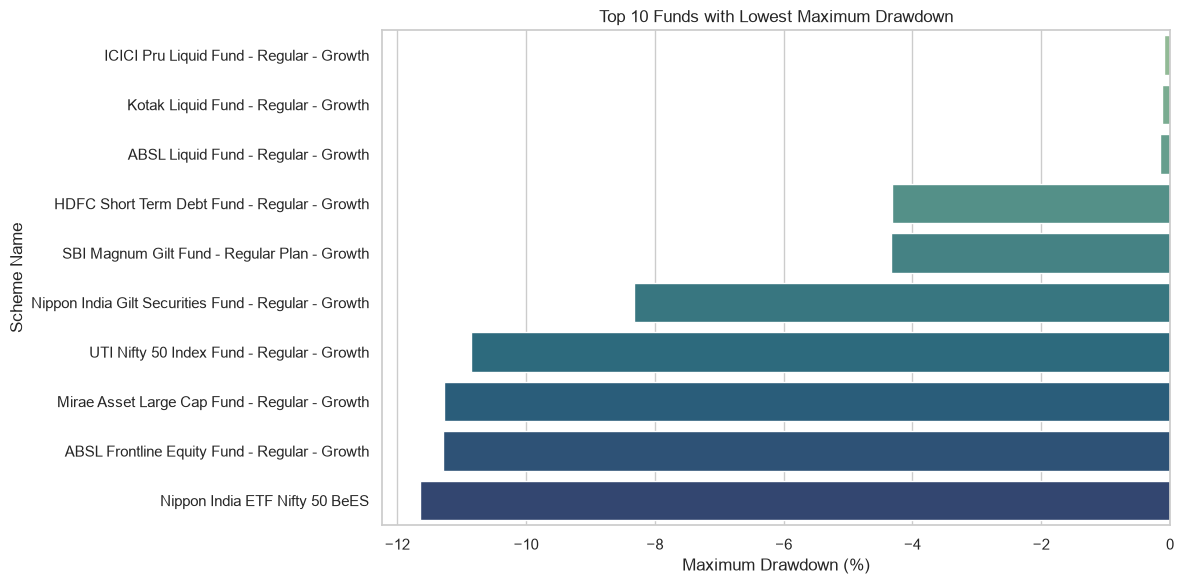

In [45]:
plt.figure(figsize=(12,6))

top10 = mdd_df.head(10)

sns.barplot(
    data=top10,
    x="Max_Drawdown",
    y="scheme_name",
    hue="scheme_name",
    palette="crest",
    legend=False
)

plt.title("Top 10 Funds with Lowest Maximum Drawdown")

plt.xlabel("Maximum Drawdown (%)")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.show()

In [46]:
mdd_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

print("maximum_drawdown.csv saved successfully!")

maximum_drawdown.csv saved successfully!


## Insight 6

Maximum Drawdown measures the largest peak-to-trough decline experienced by a fund during the analysis period. Funds with smaller drawdowns were more resilient during market downturns and generally exhibited stronger downside risk management.

In [47]:
# Prepare required columns

scorecard = performance[
    ["amfi_code", "scheme_name", "expense_ratio_pct", "return_3yr_pct"]
].copy()

scorecard.head()

,amfi_code,scheme_name,expense_ratio_pct,return_3yr_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54,12.36
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.66,11.30
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.43,23.39
3,119599,SBI Small Cap Fund - Direct Plan - Growth,0.72,23.14
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77,6.07


In [48]:
# Merge Sharpe Ratio
scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="left"
)

# Merge Alpha
scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code",
    how="left"
)

# Merge Maximum Drawdown
scorecard = scorecard.merge(
    mdd_df[["amfi_code", "Max_Drawdown"]],
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,scheme_name,expense_ratio_pct,return_3yr_pct,Sharpe_Ratio,Alpha,Max_Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54,12.36,1.208,0.232010,-15.01
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.66,11.30,0.953,0.198686,-11.80
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.43,23.39,0.945,0.303370,-28.71
3,119599,SBI Small Cap Fund - Direct Plan - Growth,0.72,23.14,-0.057,0.048824,-52.57
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77,6.07,-0.227,0.056209,-4.33


In [49]:
# Higher is better
scorecard["Return_Rank"] = scorecard["return_3yr_pct"].rank(ascending=False)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)

# Lower is better
scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["Drawdown_Rank"] = scorecard["Max_Drawdown"].rank(ascending=False)

scorecard.head()

,amfi_code,scheme_name,expense_ratio_pct,return_3yr_pct,Sharpe_Ratio,Alpha,Max_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54,12.36,1.208,0.232010,-15.01,26.0,4.0,10.0,30.5,17.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.66,11.30,0.953,0.198686,-11.80,34.0,12.0,15.0,4.0,11.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.43,23.39,0.945,0.303370,-28.71,1.0,14.0,1.0,21.0,36.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,0.72,23.14,-0.057,0.048824,-52.57,2.0,32.0,36.0,5.5,40.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77,6.07,-0.227,0.056209,-4.33,38.0,37.0,34.0,9.0,5.0


In [50]:
scorecard["Score"] = (

    (scorecard["Return_Rank"] * 0.30)

    +

    (scorecard["Sharpe_Rank"] * 0.25)

    +

    (scorecard["Alpha_Rank"] * 0.20)

    +

    (scorecard["Expense_Rank"] * 0.15)

    +

    (scorecard["Drawdown_Rank"] * 0.10)

)

In [51]:
# Normalize score

min_score = scorecard["Score"].min()

max_score = scorecard["Score"].max()

scorecard["Fund_Score"] = (
    (scorecard["Score"] - min_score)
    /
    (max_score - min_score)
) * 100

scorecard["Fund_Score"] = scorecard["Fund_Score"].round(2)

In [52]:
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.reset_index(drop=True, inplace=True)

scorecard.head(10)

,amfi_code,scheme_name,expense_ratio_pct,return_3yr_pct,Sharpe_Ratio,Alpha,Max_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Score,Fund_Score
0,101208,ABSL Liquid Fund - Regular - Growth,0.79,5.14,-0.816,0.060861,-0.16,40.0,40.0,33.0,11.0,3.0,30.550,100.00
1,119092,Axis Bluechip Fund - Regular - Growth,1.64,11.84,0.031,0.068995,-14.40,31.0,31.0,30.0,39.5,15.0,30.475,99.65
2,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.55,14.84,-0.202,0.037476,-24.73,16.0,35.0,39.0,32.0,34.0,29.550,95.36
3,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77,6.07,-0.227,0.056209,-4.33,38.0,37.0,34.0,9.0,5.0,29.300,94.20
4,118636,Nippon India Gilt Securities Fund - Regular - ...,0.55,5.31,-0.357,0.050748,-8.32,39.0,38.0,35.0,1.0,6.0,28.950,92.58
5,100025,HDFC Short Term Debt Fund - Regular - Growth,0.56,7.37,-0.567,0.042818,-4.31,36.0,39.0,38.0,2.0,4.0,28.850,92.11
6,102886,UTI Mid Cap Fund - Regular - Growth,1.51,15.61,-0.206,0.028969,-28.00,12.0,36.0,40.0,24.5,35.0,27.775,87.12
7,120841,Kotak Bluechip Fund - Regular - Growth,1.59,12.25,0.494,0.130429,-17.57,28.0,24.0,25.0,35.0,24.0,27.050,83.76
8,120844,Kotak Liquid Fund - Regular - Growth,0.60,6.18,-0.089,0.064557,-0.12,37.0,34.0,32.0,3.0,2.0,26.650,81.90
9,119093,Axis Bluechip Fund - Direct - Growth,0.75,12.14,0.130,0.082328,-21.75,29.0,29.0,28.0,8.0,31.0,25.850,78.19


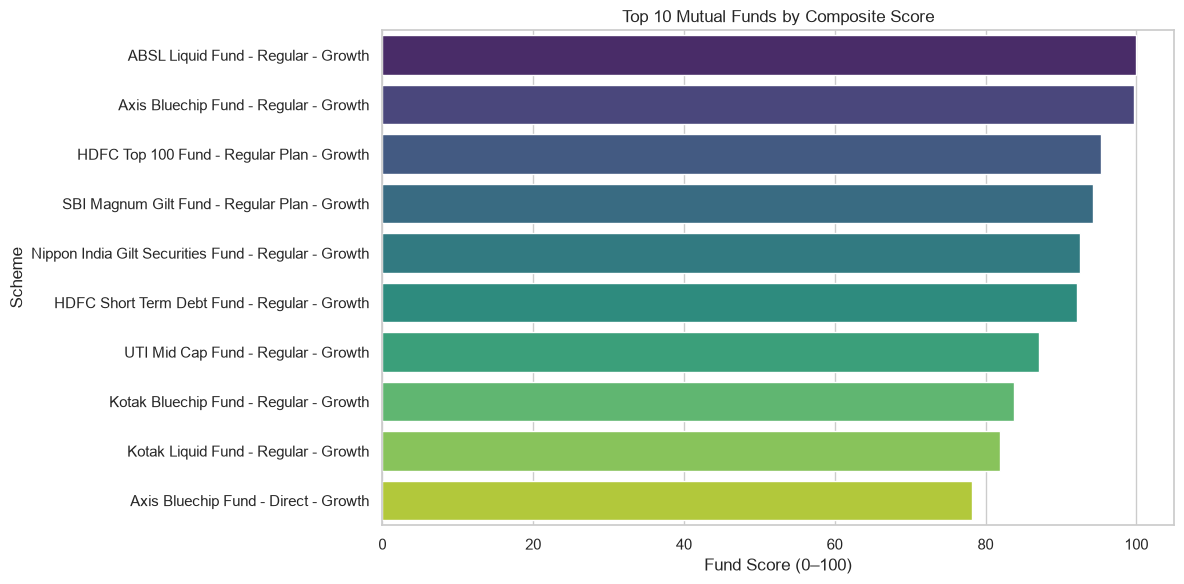

In [53]:
plt.figure(figsize=(12,6))

top10 = scorecard.head(10)

sns.barplot(
    data=top10,
    x="Fund_Score",
    y="scheme_name",
    hue="scheme_name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Mutual Funds by Composite Score")

plt.xlabel("Fund Score (0–100)")

plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

In [54]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv created successfully!")

fund_scorecard.csv created successfully!


## Insight 7

The composite fund score combines returns, risk-adjusted performance, expense ratio, alpha, and drawdown into a single performance indicator. Funds with higher scores consistently delivered strong returns while maintaining lower costs and better downside protection.

In [55]:
# Select Top 5 funds from the scorecard
top5_codes = scorecard.head(5)["amfi_code"].tolist()

top5_codes

[101208, 119092, 100016, 119120, 118636]

In [56]:
top5_nav = nav_history[
    nav_history["amfi_code"].isin(top5_codes)
].copy()

top5_nav = top5_nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top5_nav.head()

,amfi_code,date,nav,daily_return,scheme_name
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth


In [57]:
benchmark_filtered = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_filtered.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [58]:
import plotly.express as px

fig = px.line(
    top5_nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="Top 5 Mutual Funds NAV Comparison"
)

fig.update_layout(
    width=1200,
    height=650,
    template="plotly_white"
)

fig.show()

In [59]:
fig = px.line(
    benchmark_filtered,
    x="date",
    y="close_value",
    color="index_name",
    title="NIFTY50 vs NIFTY100"
)

fig.update_layout(
    width=1200,
    height=650,
    template="plotly_white"
)

fig.show()

In [60]:
import plotly.graph_objects as go

fig = go.Figure()

# Top 5 Funds
for scheme in top5_nav["scheme_name"].unique():

    data = top5_nav[
        top5_nav["scheme_name"] == scheme
    ]

    fig.add_trace(
        go.Scatter(
            x=data["date"],
            y=data["nav"],
            mode="lines",
            name=scheme
        )
    )

# Benchmarks
for idx in benchmark_filtered["index_name"].unique():

    data = benchmark_filtered[
        benchmark_filtered["index_name"] == idx
    ]

    fig.add_trace(
        go.Scatter(
            x=data["date"],
            y=data["close_value"],
            mode="lines",
            name=idx,
            line=dict(dash="dash")
        )
    )

fig.update_layout(
    title="Top 5 Mutual Funds vs Benchmark Indices",
    width=1400,
    height=700,
    template="plotly_white"
)

fig.show()

In [61]:
tracking_results = []

# Benchmark returns
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100 = nifty100.dropna()

for amfi in top5_codes:

    fund = daily_returns[
        daily_returns["amfi_code"] == amfi
    ][["date", "daily_return"]]

    merged = pd.merge_asof(
        fund.sort_values("date"),
        nifty100[["date", "benchmark_return"]].sort_values("date"),
        on="date"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_results.append({
        "amfi_code": amfi,
        "Tracking_Error": round(tracking_error, 4)
    })

tracking_df = pd.DataFrame(tracking_results)

tracking_df

,amfi_code,Tracking_Error
0,101208,0.1290
1,119092,0.1891
2,100016,0.1993
3,119120,0.1356
4,118636,0.1348


In [62]:
tracking_df = tracking_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

tracking_df

,amfi_code,Tracking_Error,scheme_name
0,101208,0.1290,ABSL Liquid Fund - Regular - Growth
1,119092,0.1891,Axis Bluechip Fund - Regular - Growth
2,100016,0.1993,HDFC Top 100 Fund - Regular Plan - Growth
3,119120,0.1356,SBI Magnum Gilt Fund - Regular Plan - Growth
4,118636,0.1348,Nippon India Gilt Securities Fund - Regular - ...


In [63]:
tracking_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("tracking_error.csv created successfully!")

tracking_error.csv created successfully!


In [64]:
fig.write_html("../reports/benchmark_comparison.html")

## Insight 8

The benchmark comparison demonstrates how the highest-ranked mutual funds performed relative to the NIFTY50 and NIFTY100 indices. Tracking Error measures how closely each fund follows the benchmark. Lower tracking error indicates performance closer to the benchmark, while higher tracking error reflects greater active management.